# Plot SSS and upper ocean stratification using in situ data

In [78]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import glob
from pathlib import Path
from pprint import pprint
import gsw
import os
from datetime import datetime, timedelta
import h5py

## Load data

### In situ obs

In [81]:
# open UCTD dataset
uctd_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/UCTD/SASSIE_Fall_2022_shipboard_underwayCTD.nc')
# open Castaway CTD dataset
cctd_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/CASTAWAY_CTD/SASSIE_Fall_2022_SHIPBOARD_Castaway_CTD.nc')
# open float data
float_11131_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/ALTO_ALAMO_FLOATS/SASSIE_Fall_2022_ALAMO_ALTO_11131.nc')
float_11132_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/ALTO_ALAMO_FLOATS/SASSIE_Fall_2022_ALAMO_ALTO_11132.nc')
float_11133_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/ALTO_ALAMO_FLOATS/SASSIE_Fall_2022_ALAMO_ALTO_11133.nc')
float_11136_ds = xr.open_dataset('/Users/mzahn/data/SASSIE/obs/ALTO_ALAMO_FLOATS/SASSIE_Fall_2022_ALAMO_ALTO_11136.nc')

Get date range

In [84]:
print("START")
print(np.sort(uctd_ds.time.values)[0])
print(np.sort(cctd_ds.time.values)[0])
print(np.sort(float_11131_ds.time.values)[0])
print(np.sort(float_11132_ds.time.values)[0])
print(np.sort(float_11133_ds.time.values)[0])
print(np.sort(float_11136_ds.time.values)[0])

START
2022-09-09T03:55:01.326913280
2022-09-09T15:22:59.999998208
2022-09-08T20:39:00.000004608
2022-09-09T03:33:00.000002560
2022-09-08T14:40:00.000001024
2022-09-09T00:14:59.999996672


In [86]:
print("END")
print(np.sort(uctd_ds.time.values)[-1])
print(np.sort(cctd_ds.time.values)[-1])
print(np.sort(float_11131_ds.time.values)[-1])
print(np.sort(float_11132_ds.time.values)[-1])
print(np.sort(float_11133_ds.time.values)[-1])
print(np.sort(float_11136_ds.time.values)[-1])

END
2022-09-29T12:14:05.433203456
2022-09-19T00:27:00.000004096
2022-10-14T18:39:00.000001280
2022-10-14T02:56:00.000004352
2022-10-14T08:23:00.000001536
2022-10-14T15:30:00.000003328


### Sea ice dataset from Astrid

In [89]:
# look at example netcdf for metadata and data structure
sic_2022_ds = xr.open_dataset('/Users/mzahn/data/sic_astrid/netCDF_files/nws_2022.nc')
sic_2022_ds

<xarray.Dataset>
Dimensions:    (y: 1003, x: 501, z: 365)
Dimensions without coordinates: y, x, z
Data variables:
    LAT        (y, x) float64 ...
    LON        (y, x) float64 ...
    date       (z) float64 ...
    iceconc    (z, y, x) float64 ...
    rangeconc  (z, y, x) float64 ...
    eggcode    (z, y, x) float64 ...
    flag       (z, y, x) float64 ...
    area       (z, y, x) float64 ...
    amt_poly   (z) float64 ...

In [91]:
sic_mat_path = Path('/Users/mzahn/data/sic_astrid/')
sic_mat_list = np.sort(list(sic_mat_path.glob('*.mat')))

In [93]:
# open .mat file using h5py
with h5py.File(sic_mat_list[-1], 'r') as f:
    # read the keys and corresponding data
    LAT = np.array(f['LAT'])  # Shape (1003, 501)
    LON = np.array(f['LON'])  # Shape (1003, 501)
    
    # convert matlab dates to python datetime objects
    date = []
    for i in range(len(f['date'])):
        time = datetime.fromordinal(int(sic_2022_ds.date.values[i])) + timedelta(days=sic_2022_ds.date.values[i]%1) - timedelta(days = 366)
        date.append(np.datetime64(time,'ns'))
    
    # read data variables, ensuring they match their given dimensions
    iceconc = np.array(f['iceconc'])  # Shape (365, 1003, 501)
    rangeconc = np.array(f['rangeconc'])  # Shape (365, 1003, 501)
    eggcode = np.array(f['eggcode'])  # Shape (365, 1003, 501)
    flag = np.array(f['flag'])  # Shape (365, 1003, 501)
    area = np.array(f['area'])  # Shape (365, 1003, 501)
    amt_poly = np.array(f['amt_poly'])  # Shape (365,)

# create an xarray Dataset
siconc_ds = xr.Dataset(
    {
        'iceconc': (['time', 'y', 'x'], iceconc),
        'rangeconc': (['time', 'y', 'x'], rangeconc),
        'eggcode': (['time', 'y', 'x'], eggcode),
        'flag': (['time', 'y', 'x'], flag),
        'area': (['time', 'y', 'x'], area),
        'amt_poly': (['time'], amt_poly.reshape(365))
    },
    coords={
        'lat': (['y', 'x'], LAT),
        'lon': (['y', 'x'], LON),
        'time': date
    }
)

In [94]:
siconc_ds.iceconc.isel(date=100).plot()

ValueError: Dimensions {'date'} do not exist. Expected one or more of ('time', 'y', 'x')

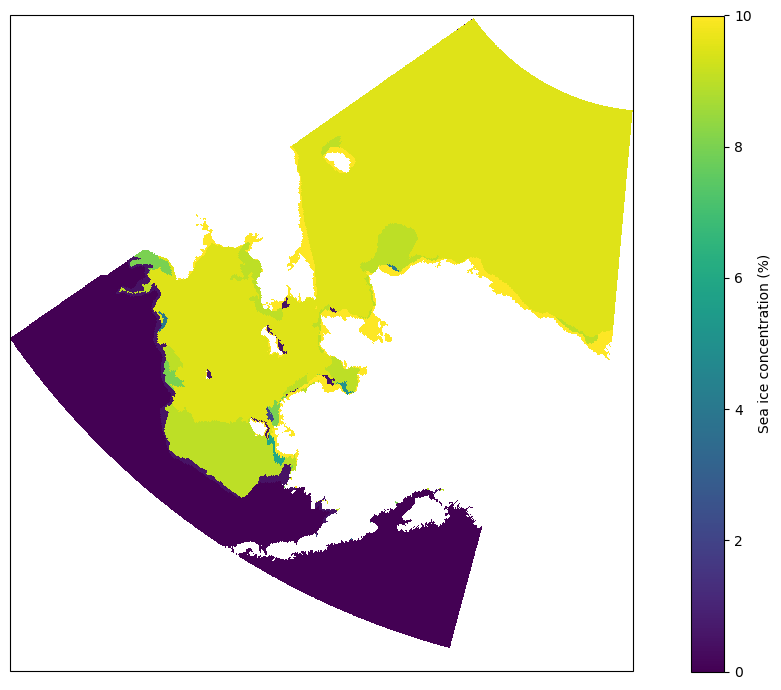

In [451]:
fig, ax = plt.subplots(1,1,figsize=(12,7),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

# ax.set_extent([-160, -135, 70, 75], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
# ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
# ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

ice = ax.pcolormesh(sic_2022_ds.LON.values,sic_2022_ds.LAT.values,ds.iceconc.isel(date=100).values,vmin=0,vmax=10,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Sea ice concentration (%)')
fig.tight_layout()

### Download and open sea ice conc

#### Download

Sea Ice Concentration/Aggregated AMSR-2 Sea Ice Concentration (OSI-408) for the Northern Hemisphere Polar Stereographic Projection

Using product from https://osi-saf.eumetsat.int/products/osi-408-a<br>
Ice concentration is computed from atmospherically corrected AMSR-2 brightness temperatures<br>
OSI SAF Global Sea Ice Concentration (AMSR-2), OSI-408-a, doi: 10.15770/EUM_SAF_OSI_NRT_2023. EUMETSAT Ocean and Sea Ice Satellite Application Facility.<br>

In [ ]:
from datetime import datetime, timedelta

In [ ]:
output_dir = "/Users/mzahn/data/AMSR-2/"

In [ ]:
# Set the start and end dates for the loop
start_date = datetime(2022, 9, 1)
end_date = datetime(2022, 10, 15)

# Loop through the date range
date = start_date
while date <= end_date:
    
    # Extract the year, month, and day
    year = date.strftime("%Y")
    month = date.strftime("%m")
    day = date.strftime("%d")
    
    # Print the values
    print(f"Downloading Year: {year}, Month: {month}, Day: {day}")
    
    thredds_server = 'https://thredds.met.no/thredds/fileServer/osisaf/met.no/ice/amsr2_conc/'
    name_prefix = "ice_conc_nh_polstere-100_amsr2_"
    name_suffix = "1200.nc"
    
    os.system('wget '+thredds_server+year+'/'+month+'/'+name_prefix+year+month+day+name_sufix+' -P '+output_dir+' -q')
    
    # Increment the date by 1 day
    date += timedelta(days=1)

#### Open

In [13]:
# list all files
SI_file_list = list(Path("/Users/mzahn/data/AMSR-2/").glob("*.nc"))

In [15]:
# open dataset
SI_conc_ds = xr.open_mfdataset(SI_file_list)
SI_conc_ds.close()

## Plot locations of in situ data

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
import matplotlib.patches as mpatches

In [96]:
# AMSR-2
# SI_over15 = SI_conc_ds.ice_conc.where(SI_conc_ds.ice_conc>15)

# SASSIE
siconc_over0_ds = siconc_ds.iceconc.where(siconc_ds.iceconc>0)

In [ ]:
# take average over this period (Sept-mid Oct)
SI_conc_avg = SI_conc_ds.ice_conc.mean(dim='time')
SI_avg_over15 = SI_conc_avg.where(SI_conc_avg>15)

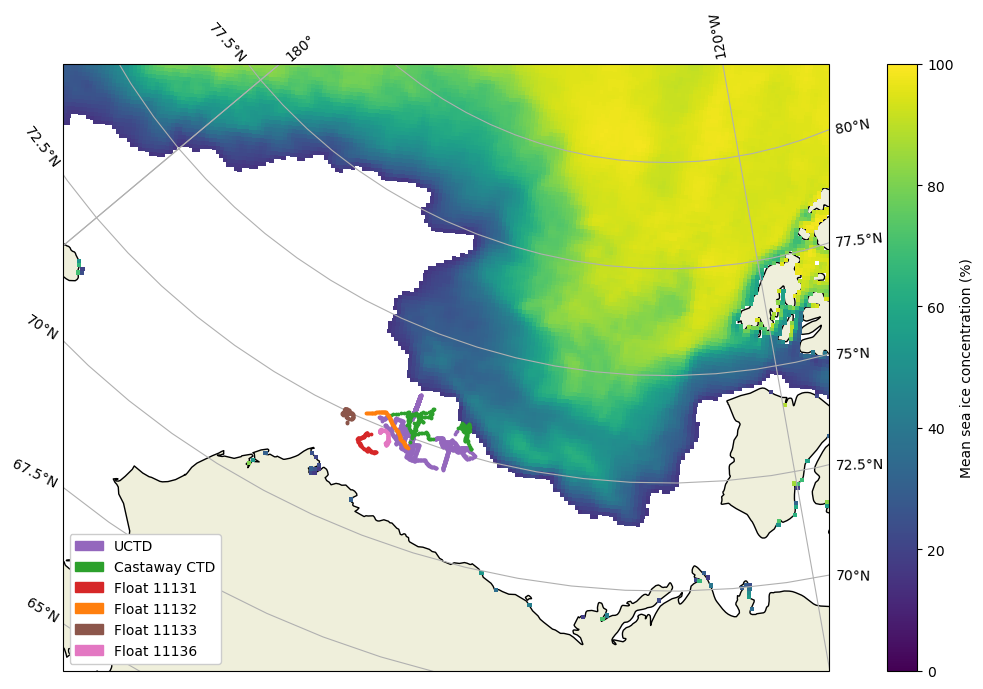

In [487]:
fig, ax = plt.subplots(1,1,figsize=(12,7),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-170, -120, 68, 80], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
ax.scatter(uctd_ds.longitude,uctd_ds.latitude,transform=ccrs.PlateCarree(),color='tab:purple',s=3,zorder=5)
ax.scatter(cctd_ds.longitude,cctd_ds.latitude,transform=ccrs.PlateCarree(),color='tab:green',s=3,zorder=5)
ax.scatter(float_11131_ds.longitude,float_11131_ds.latitude,transform=ccrs.PlateCarree(),color='tab:red',s=3,zorder=5)
ax.scatter(float_11132_ds.longitude,float_11132_ds.latitude,transform=ccrs.PlateCarree(),color='tab:orange',s=3,zorder=5)
ax.scatter(float_11133_ds.longitude,float_11133_ds.latitude,transform=ccrs.PlateCarree(),color='tab:brown',s=3,zorder=5)
ax.scatter(float_11136_ds.longitude,float_11136_ds.latitude,transform=ccrs.PlateCarree(),color='tab:pink',s=3,zorder=5)

# ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_over15.isel(time=0).values,vmin=0,vmax=100,\
#                     transform=ccrs.PlateCarree())
ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_avg_over15.values,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Mean sea ice concentration (%)')
fig.tight_layout()

# add legend
# colors = ['tab:orange', 'tab:purple']
# lines = [Line2D([0], [0], color=c, linewidth=3, linestyle='-') for c in colors]
# labels = ['HH','Greenland cutout']
# ax.legend(lines, labels, fontsize="14", loc ="upper center");

pt1 = mpatches.Patch(color='tab:purple', label='UCTD')
pt2 = mpatches.Patch(color='tab:green', label='Castaway CTD')
pt3 = mpatches.Patch(color='tab:red', label='Float 11131')
pt4 = mpatches.Patch(color='tab:orange', label='Float 11132')
pt5 = mpatches.Patch(color='tab:brown', label='Float 11133')
pt6 = mpatches.Patch(color='tab:pink', label='Float 11136')

# Add custom legend with the defined scatter points
ax.legend(handles=[pt1, pt2, pt3, pt4, pt5, pt6],loc='lower left',facecolor='white', framealpha=1)

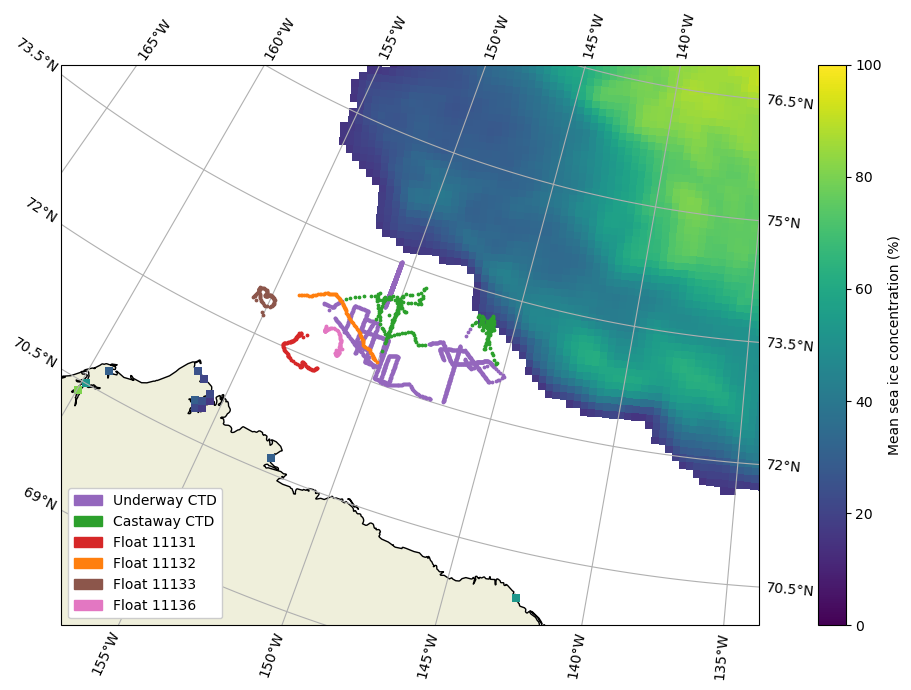

In [485]:
fig, ax = plt.subplots(1,1,figsize=(12,7),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-160, -135, 70, 75], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
ax.scatter(uctd_ds.longitude,uctd_ds.latitude,transform=ccrs.PlateCarree(),color='tab:purple',s=3,zorder=5)
ax.scatter(cctd_ds.longitude,cctd_ds.latitude,transform=ccrs.PlateCarree(),color='tab:green',s=3,zorder=5)
ax.scatter(float_11131_ds.longitude,float_11131_ds.latitude,transform=ccrs.PlateCarree(),color='tab:red',s=3,zorder=5)
ax.scatter(float_11132_ds.longitude,float_11132_ds.latitude,transform=ccrs.PlateCarree(),color='tab:orange',s=3,zorder=5)
ax.scatter(float_11133_ds.longitude,float_11133_ds.latitude,transform=ccrs.PlateCarree(),color='tab:brown',s=3,zorder=5)
ax.scatter(float_11136_ds.longitude,float_11136_ds.latitude,transform=ccrs.PlateCarree(),color='tab:pink',s=3,zorder=5)

# ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_over15.isel(time=0).values,vmin=0,vmax=100,\
#                     transform=ccrs.PlateCarree())
ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_avg_over15.values,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Mean sea ice concentration (%)')
fig.tight_layout()

# add legend
# colors = ['tab:orange', 'tab:purple']
# lines = [Line2D([0], [0], color=c, linewidth=3, linestyle='-') for c in colors]
# labels = ['HH','Greenland cutout']
# ax.legend(lines, labels, fontsize="14", loc ="upper center");

pt1 = mpatches.Patch(color='tab:purple', label='Underway CTD')
pt2 = mpatches.Patch(color='tab:green', label='Castaway CTD')
pt3 = mpatches.Patch(color='tab:red', label='Float 11131')
pt4 = mpatches.Patch(color='tab:orange', label='Float 11132')
pt5 = mpatches.Patch(color='tab:brown', label='Float 11133')
pt6 = mpatches.Patch(color='tab:pink', label='Float 11136')

# Add custom legend with the defined scatter points
ax.legend(handles=[pt1, pt2, pt3, pt4, pt5, pt6],loc='lower left',facecolor='white', framealpha=1);

### Calculate buoyancy frequency

Conversion functions: https://teos-10.github.io/GSW-Python/conversions.html

In [99]:
def get_TEOS10_and_N2(profile_ds):
    # make a copy to not modify the original
    prof_ds = profile_ds.copy(deep=True)
    
    # conversion of practical salinity to absolute salinity
    SA = gsw.SA_from_SP(prof_ds.salinity, prof_ds.temperature, prof_ds.longitude, prof_ds.latitude)
    
    # conversiotn of potential temperature (poTemp) to conservative temperature (CT)
    CT = gsw.CT_from_pt(SA, prof_ds.temperature)
    
    # calculate pressure (dbar)
    # P = gsw.p_from_z(SALT_beaufort.Z, SALT_beaufort.YC)   
    
    # Brunt Vaisala Frequency (N^2)
    # Buoyancy frequency-squared at pressure midpoints, 1/s^2. 
    # The shape along the pressure axis dimension is one less than that of the inputs. (Frequency N is in radians per second.)
    # Pressure at midpoints of p, dbar. The array shape matches N2.
    N2_all = []
    for i in range(len(SA.time.values)):
        N2, p_mid = gsw.Nsquared(SA.isel(time=i).values, CT.isel(time=i).values, prof_ds.pressure.values, prof_ds.isel(time=i).latitude.values)
        N2_all.append(N2)
    # make a DataArray
    N2_all_da = xr.DataArray(N2_all,dims=['time','p_mid'],coords=dict(time=SA.time,p_mid=p_mid))
    
    # merge datasets
    prof_ds['CT'] = CT
    prof_ds['SA'] = SA
    # add p_mid dim
    prof_ds.expand_dims(p_mid=p_mid)
    prof_ds['N2'] = N2_all_da
    
    return prof_ds

In [101]:
uctd_ds_N2 = get_TEOS10_and_N2(uctd_ds)

### First explore Underway CTD

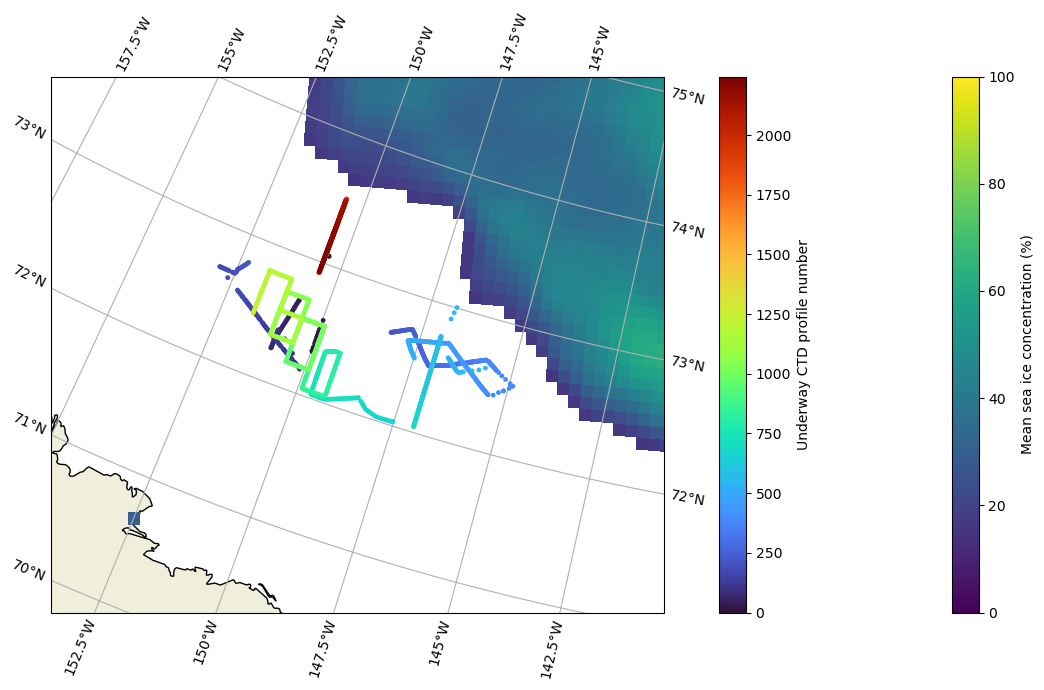

In [483]:
fig, ax = plt.subplots(1,1,figsize=(14,7),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
uctd = ax.scatter(uctd_ds.longitude,uctd_ds.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds.time)),s=6,zorder=5,cmap='turbo')

# ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_over15.isel(time=0).values,vmin=0,vmax=100,\
#                     transform=ccrs.PlateCarree())
ice = ax.pcolormesh(SI_conc_ds.lon.values,SI_conc_ds.lat.values,SI_avg_over15.values,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Mean sea ice concentration (%)')
fig.colorbar(uctd, ax=ax,label='Underway CTD profile number')
fig.tight_layout()

In [103]:
# uctd_ds_N2.isel(time=slice(2000,len(uctd_ds_N2.time)))
uctd_ds_20220929 = uctd_ds_N2.sel(time='2022-09-29')

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')

ice = ax.pcolormesh(SI_conc_ds.sel(time='2022-09-29').lon.values,SI_conc_ds.sel(time='2022-09-29').lat.values,SI_over15.sel(time='2022-09-29').isel(time=0).values,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,pad=0,label='Sea ice concentration (%)')
fig.colorbar(uctd, ax=ax,pad=0.1,label='Underway CTD profile number')
fig.tight_layout()

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

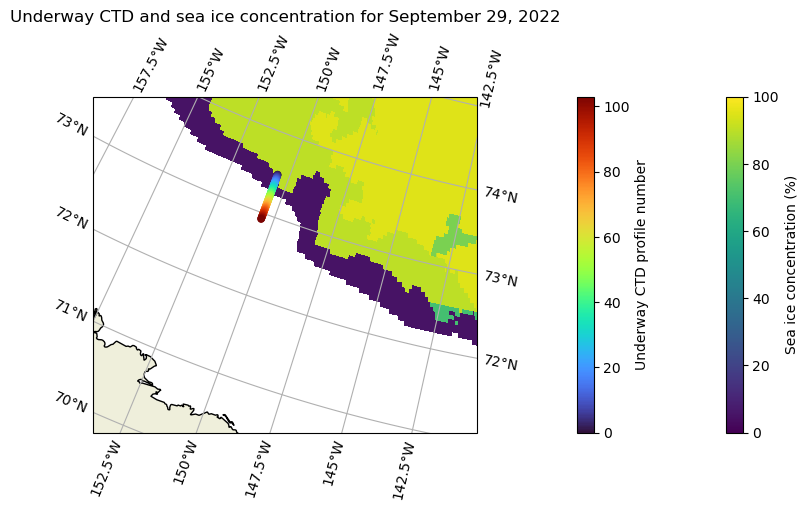

In [496]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')

ice = ax.pcolormesh(siconc_over0_ds.sel(time='2022-09-29').lon.values,siconc_over0_ds.sel(time='2022-09-29').lat.values,siconc_over0_ds.sel(time='2022-09-29').isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,pad=0,label='Sea ice concentration (%)')
fig.colorbar(uctd, ax=ax,pad=0.1,label='Underway CTD profile number')
fig.tight_layout()

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

Each degree of latitude is ~111 km apart<br>
The start and end of this subset

In [500]:
0.75*111

83.25

So they are about 80 km apart

In [107]:
# add Depth coords
depth = gsw.z_from_p(uctd_ds_20220929.pressure, uctd_ds_20220929.latitude.mean(dim='time')) 
depth.name = 'depth'

depth_mid = gsw.z_from_p(uctd_ds_20220929.p_mid, uctd_ds_20220929.latitude.mean(dim='time')) 
depth_mid.name = 'depth_mid'

In [109]:
uctd_ds_20220929 = uctd_ds_20220929.assign_coords(depth=depth)
uctd_ds_20220929 = uctd_ds_20220929.assign_coords(depth_mid=depth_mid)

In [111]:
uctd_ds_near_ice = uctd_ds_20220929.isel(time=slice(0,20))

In [113]:
uctd_ds_away_ice = uctd_ds_20220929.isel(time=slice(-20,None))

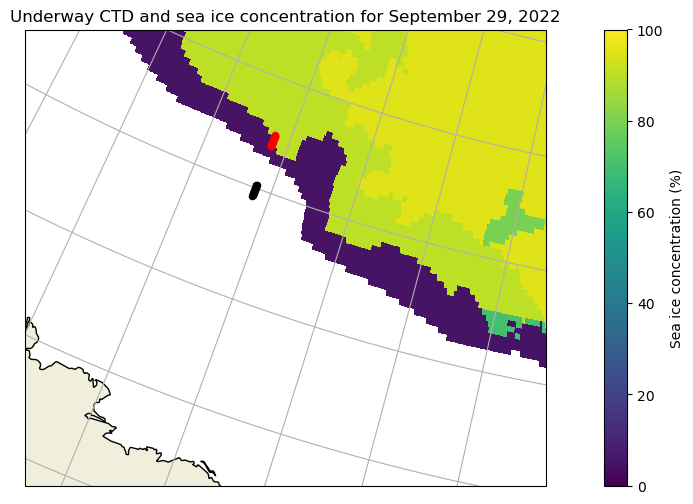

In [115]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=False, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
# uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')
ax.scatter(uctd_ds_near_ice.longitude,uctd_ds_near_ice.latitude,marker='o',transform=ccrs.PlateCarree(),c='red',s=20,zorder=5)
ax.scatter(uctd_ds_away_ice.longitude,uctd_ds_away_ice.latitude,marker='o',transform=ccrs.PlateCarree(),c='k',s=20,zorder=5)

ice = ax.pcolormesh(siconc_over0_ds.sel(time='2022-09-29').lon.values,siconc_over0_ds.sel(time='2022-09-29').lat.values,siconc_over0_ds.sel(time='2022-09-29').isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Sea ice concentration (%)')
fig.tight_layout()

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

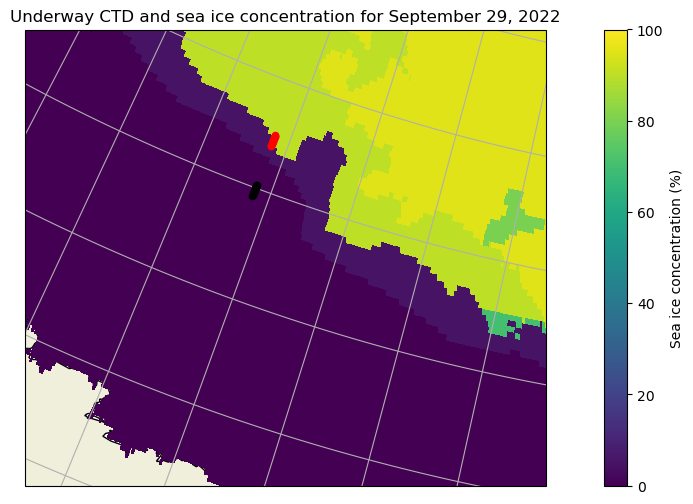

In [117]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=False, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
# uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')
ax.scatter(uctd_ds_near_ice.longitude,uctd_ds_near_ice.latitude,marker='o',transform=ccrs.PlateCarree(),c='red',s=20,zorder=5)
ax.scatter(uctd_ds_away_ice.longitude,uctd_ds_away_ice.latitude,marker='o',transform=ccrs.PlateCarree(),c='k',s=20,zorder=5)

ice = ax.pcolormesh(siconc_ds.sel(time='2022-09-29').lon.values,siconc_ds.sel(time='2022-09-29').lat.values,siconc_ds.iceconc.sel(time='2022-09-29').isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,label='Sea ice concentration (%)')
fig.tight_layout()

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

### Plot sea ice a week before and after

In [120]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/tmp/ipykernel_11072/2519167831.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


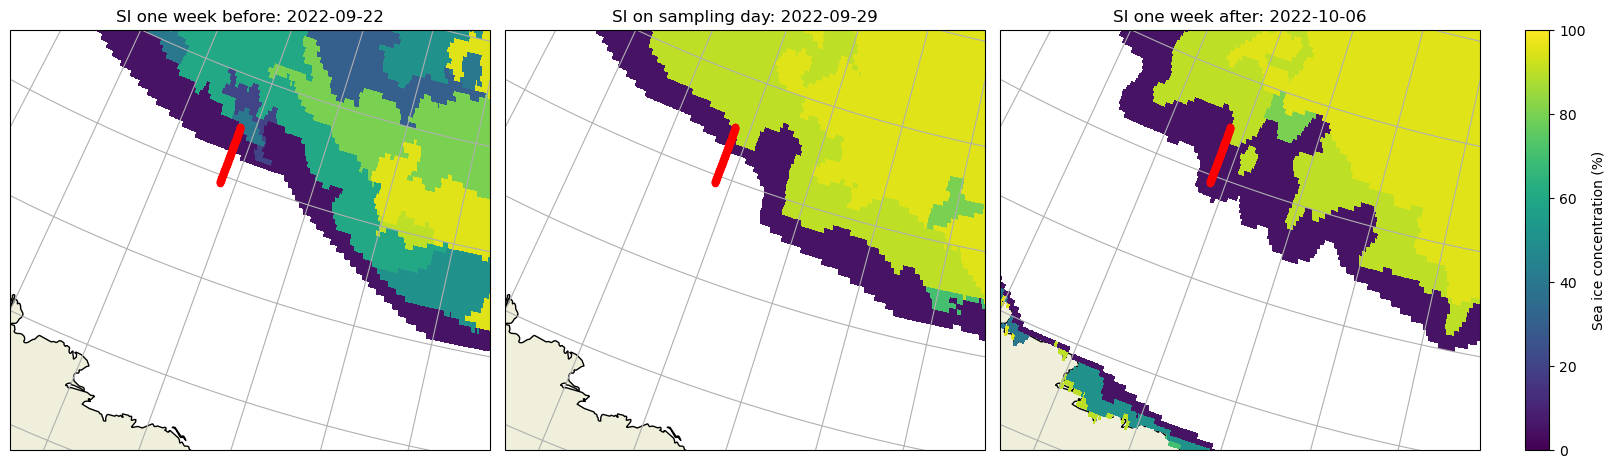

In [541]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

for ax in (ax1,ax2,ax3):
    ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
    ax.gridlines(draw_labels=False, x_inline=False, y_inline=False)
    ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

    # add in situ data
    uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c='red',s=20,zorder=5)

# one week before
date = '2022-09-22'
ax1.pcolormesh(siconc_over0_ds.sel(time=date).lon.values,siconc_over0_ds.sel(time=date).lat.values,siconc_over0_ds.sel(time=date).isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())

# sampling day
date = '2022-09-29'
ax2.pcolormesh(siconc_over0_ds.sel(time=date).lon.values,siconc_over0_ds.sel(time=date).lat.values,siconc_over0_ds.sel(time=date).isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())

# a week after
date = '2022-10-06'
ice = ax3.pcolormesh(siconc_over0_ds.sel(time=date).lon.values,siconc_over0_ds.sel(time=date).lat.values,siconc_over0_ds.sel(time=date).isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())

axins = inset_axes(ax3, width="5%",   height="100%", loc='center right', borderpad=-5)
fig.colorbar(ice, cax=axins, orientation="vertical", label='Sea ice concentration (%)')

# plt.title('Underway CTD locations and sea ice concentration for September 29, 2022');
ax1.set_title("SI one week before: 2022-09-22")
ax2.set_title("SI on sampling day: 2022-09-29")
ax3.set_title("SI one week after: 2022-10-06");

fig.tight_layout()

In [50]:
from datetime import datetime, timedelta

start_date = datetime(2022, 9, 25)
end_date = datetime(2022, 10, 3)
dates = [(start_date + timedelta(days=x)).strftime('%Y-%m-%d') for x in range((end_date - start_date).days + 1)]

/tmp/ipykernel_11072/2652235631.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


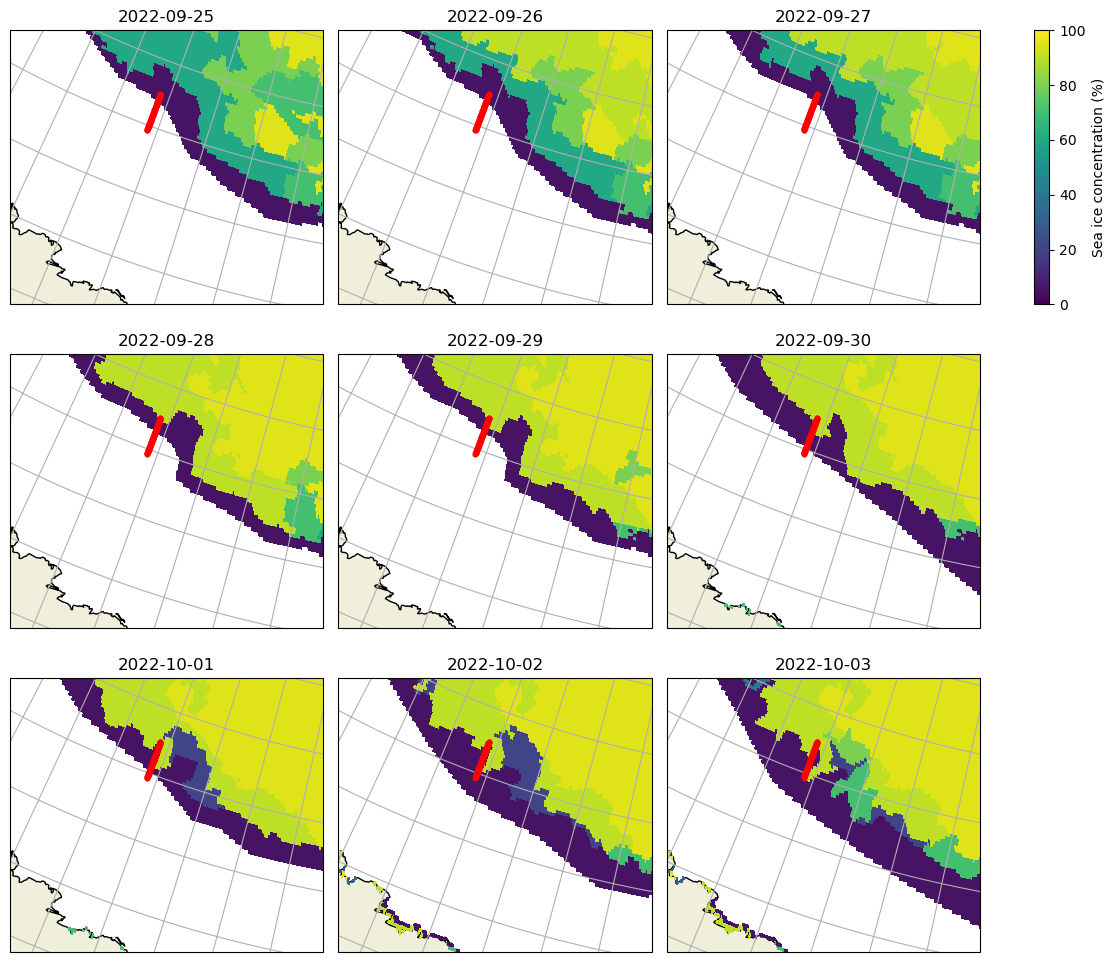

In [593]:
fig, axes = plt.subplots(3,3,figsize=(10,10),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})
axes = axes.flatten()

for ax,date in zip(axes,dates):
    ax.set_extent([-155, -142, 71, 74], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
    ax.gridlines(draw_labels=False, x_inline=False, y_inline=False)
    ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')
    
    # add in situ data
    uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c='red',s=10,zorder=5)
    ice = ax.pcolormesh(siconc_over0_ds.sel(time=date).lon.values,siconc_over0_ds.sel(time=date).lat.values,\
                        siconc_over0_ds.sel(time=date).isel(time=0).values*10,vmin=0,vmax=100,transform=ccrs.PlateCarree())
    ax.set_title(date)
    
axins = inset_axes(axes[2], width="5%",   height="100%", loc='center right', borderpad=-5)
fig.colorbar(ice, cax=axins, orientation="vertical", label='Sea ice concentration (%)');
fig.tight_layout()

/tmp/ipykernel_11072/4117888284.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


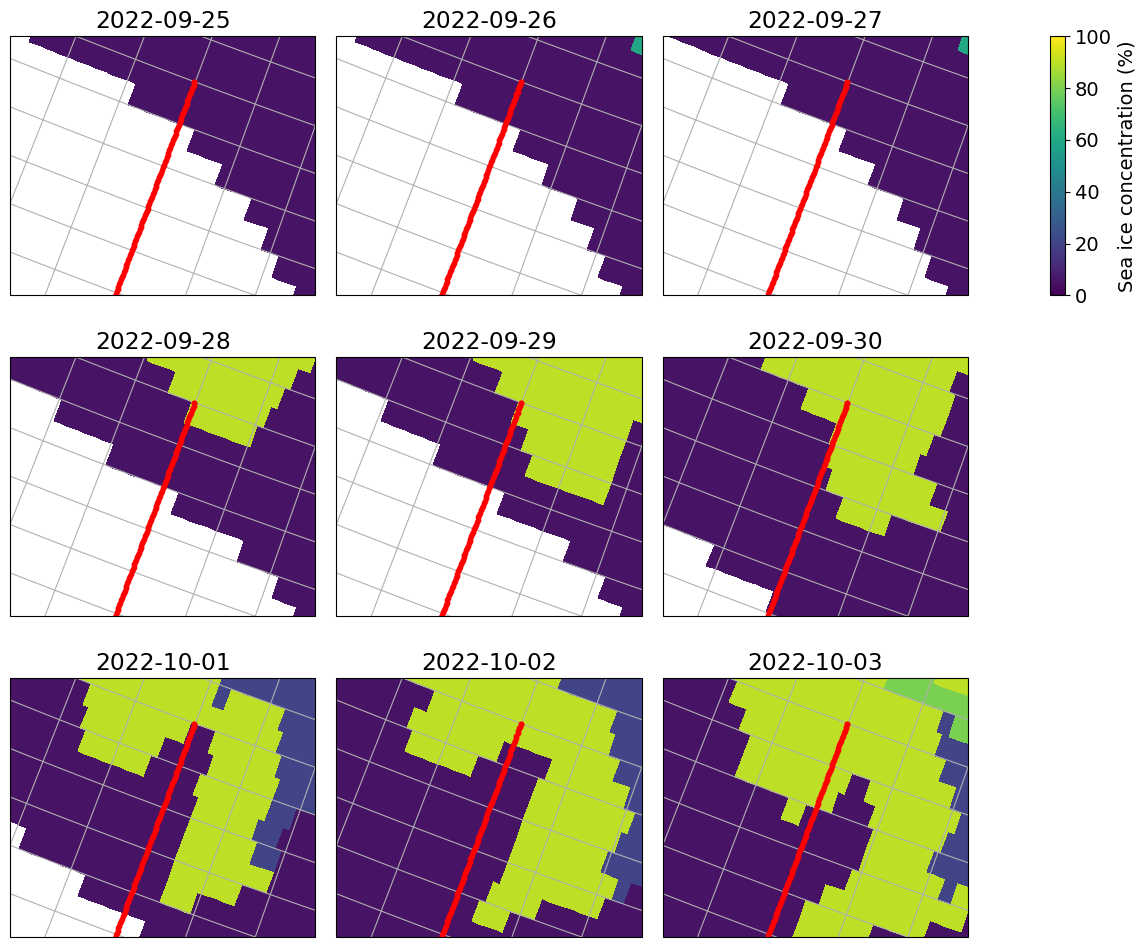

In [1192]:
fig, axes = plt.subplots(3,3,figsize=(10,10),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})
axes = axes.flatten()

for ax,date in zip(axes,dates):
    ax.set_extent([-151.5, -149.5, 73.1, 73.5], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
    ax.gridlines(draw_labels=False, x_inline=False, y_inline=False)
    ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')
    
    # add in situ data
    uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c='red',s=10,zorder=5)
    ice = ax.pcolormesh(siconc_over0_ds.sel(time=date).lon.values,siconc_over0_ds.sel(time=date).lat.values,\
                        siconc_over0_ds.sel(time=date).isel(time=0).values*10,vmin=0,vmax=100,transform=ccrs.PlateCarree())
    ax.set_title(date)
    
axins = inset_axes(axes[2], width="5%",   height="100%", loc='center right', borderpad=-5)
fig.colorbar(ice, cax=axins, orientation="vertical", label='Sea ice concentration (%)');
fig.tight_layout()

### Plot profiles

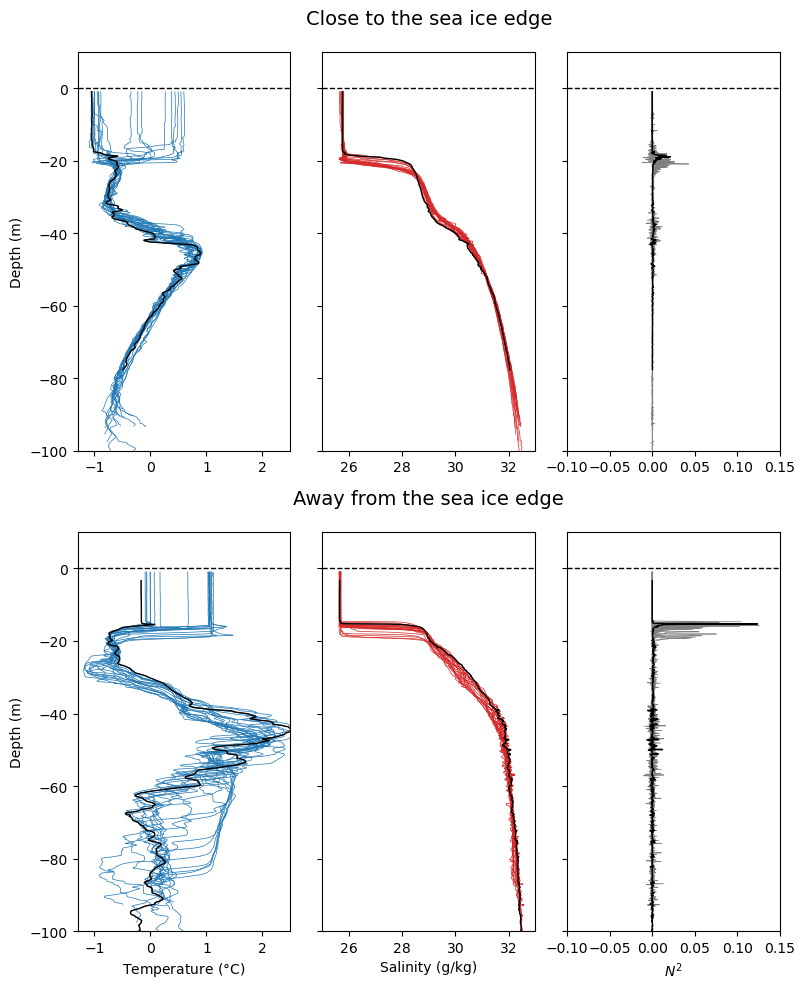

In [122]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,sharey=True,figsize=[8,10])

# plot all underway ctd profiles
linewidth_size = 0.5
uctd_ds_near_ice.CT.plot(ax=ax1,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
uctd_ds_near_ice.SA.plot(ax=ax2,y='depth',hue='time',c='tab:red',add_legend=False,linewidth=linewidth_size)
uctd_ds_near_ice.N2.plot(ax=ax3,y='depth_mid',hue='time',c='gray',add_legend=False,linewidth=linewidth_size)

uctd_ds_away_ice.CT.plot(ax=ax4,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size);
uctd_ds_away_ice.SA.plot(ax=ax5,y='depth',hue='time',c='tab:red',add_legend=False,linewidth=linewidth_size);
uctd_ds_away_ice.N2.plot(ax=ax6,y='depth_mid',hue='time',c='gray',add_legend=False,linewidth=linewidth_size);

# plot closest and farthest one for this day
linewidth_size = 1
uctd_ds_20220929.isel(time=1).CT.plot(ax=ax1,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size)
uctd_ds_20220929.isel(time=1).SA.plot(ax=ax2,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size)
uctd_ds_20220929.isel(time=1).N2.plot(ax=ax3,y='depth_mid',hue='time',c='k',add_legend=False,linewidth=linewidth_size)

uctd_ds_20220929.isel(time=-1).CT.plot(ax=ax4,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size);
uctd_ds_20220929.isel(time=-1).SA.plot(ax=ax5,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size);
uctd_ds_20220929.isel(time=-1).N2.plot(ax=ax6,y='depth_mid',hue='time',c='k',add_legend=False,linewidth=linewidth_size);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6):
    ax.set_ylim(-100,10)
    ax.axhline(y=0,c='k',linewidth=linewidth_size,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-1.3,2.5)
ax4.set_xlim(-1.3,2.5)
ax2.set_xlim(25,33)
ax5.set_xlim(25,33)
ax3.set_xlim(-0.1,0.15)
ax6.set_xlim(-0.1,0.15);

ax2.set_title("Close to the sea ice edge",size=14,pad=20)
ax5.set_title("Away from the sea ice edge",size=14,pad=20)

ax1.set_ylabel("Depth (m)")
ax4.set_ylabel("Depth (m)")
ax4.set_xlabel("Temperature ($\degree$C)")
ax5.set_xlabel("Salinity (g/kg)")
ax6.set_xlabel("$N^2$")

plt.tight_layout()

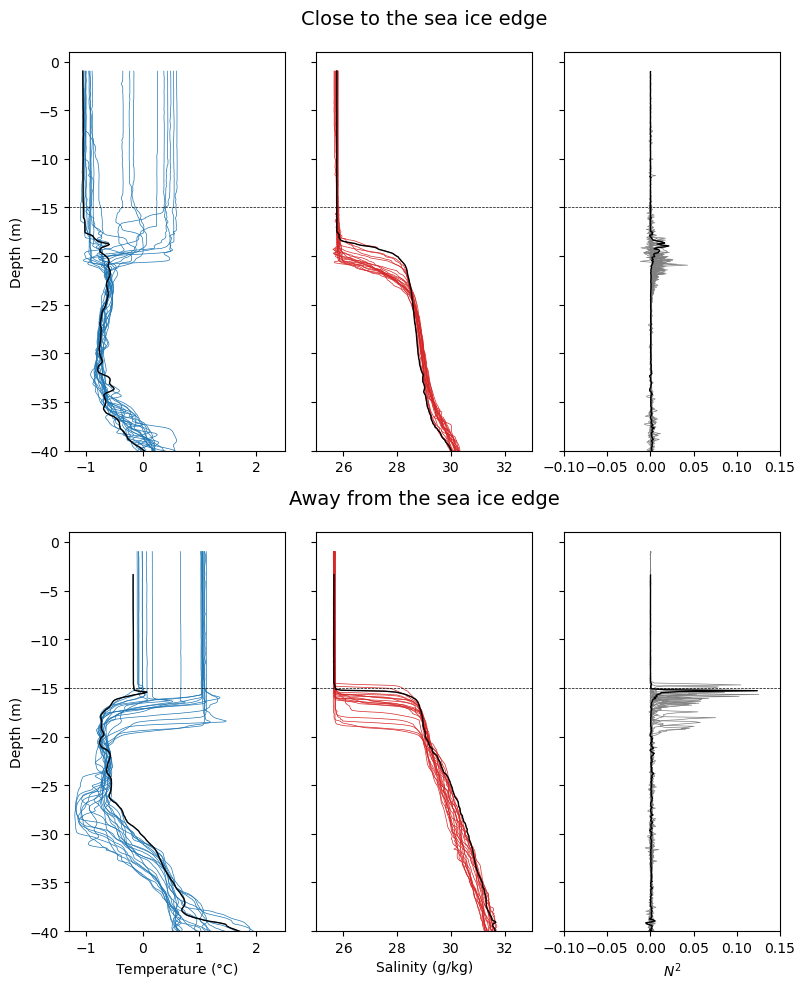

In [554]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,sharey=True,figsize=[8,10])

# plot all underway ctd profiles
linewidth_size = 0.5
uctd_ds_near_ice.CT.plot(ax=ax1,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
uctd_ds_near_ice.SA.plot(ax=ax2,y='depth',hue='time',c='tab:red',add_legend=False,linewidth=linewidth_size)
uctd_ds_near_ice.N2.plot(ax=ax3,y='depth_mid',hue='time',c='gray',add_legend=False,linewidth=linewidth_size)

uctd_ds_away_ice.CT.plot(ax=ax4,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size);
uctd_ds_away_ice.SA.plot(ax=ax5,y='depth',hue='time',c='tab:red',add_legend=False,linewidth=linewidth_size);
uctd_ds_away_ice.N2.plot(ax=ax6,y='depth_mid',hue='time',c='gray',add_legend=False,linewidth=linewidth_size);

# plot closest and farthest one for this day
linewidth_size = 1
uctd_ds_20220929.isel(time=1).CT.plot(ax=ax1,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size)
uctd_ds_20220929.isel(time=1).SA.plot(ax=ax2,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size)
uctd_ds_20220929.isel(time=1).N2.plot(ax=ax3,y='depth_mid',hue='time',c='k',add_legend=False,linewidth=linewidth_size)

uctd_ds_20220929.isel(time=-1).CT.plot(ax=ax4,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size);
uctd_ds_20220929.isel(time=-1).SA.plot(ax=ax5,y='depth',hue='time',c='k',add_legend=False,linewidth=linewidth_size);
uctd_ds_20220929.isel(time=-1).N2.plot(ax=ax6,y='depth_mid',hue='time',c='k',add_legend=False,linewidth=linewidth_size);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6):
    ax.set_ylim(-40,1)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-1.3,2.5)
ax4.set_xlim(-1.3,2.5)
ax2.set_xlim(25,33)
ax5.set_xlim(25,33)
ax3.set_xlim(-0.1,0.15)
ax6.set_xlim(-0.1,0.15);

ax2.set_title("Close to the sea ice edge",size=14,pad=20)
ax5.set_title("Away from the sea ice edge",size=14,pad=20)

ax1.set_ylabel("Depth (m)")
ax4.set_ylabel("Depth (m)")
ax4.set_xlabel("Temperature ($\degree$C)")
ax5.set_xlabel("Salinity (g/kg)")
ax6.set_xlabel("$N^2$")

plt.tight_layout()

### Plot transect of profiles

Ship was transiting from the ice edge going towards shore (away from ice edge)

In [124]:
from geopy.distance import geodesic

In [126]:
temp_da = uctd_ds_20220929.CT.swap_dims({"pressure":"depth"})
salt_da = uctd_ds_20220929.SA.swap_dims({"pressure":"depth"})
N2_da = uctd_ds_20220929.N2.swap_dims({"p_mid":"depth_mid"})

In [128]:
# make convention for depth coord positive down
temp_da['depth'] = temp_da.depth*-1
salt_da['depth'] = salt_da.depth*-1
N2_da['depth_mid'] = N2_da.depth_mid*-1

In [130]:
def generate_distance_array(da):
    distance = [0] # add zero for first point

    for i in range(len(da.time)-1):
        # coordinates of two locations (latitude, longitude)
        coords_1 = (da.latitude.isel(time=i), da.longitude.isel(time=i))
        coords_2 = (da.latitude.isel(time=i+1), da.longitude.isel(time=i+1))
    
        # calculate distance
        distance.append(geodesic(coords_1, coords_2).kilometers)
    
    # calculate cumulative sum
    distance_cumsum = np.cumsum(distance)
    
    return distance_cumsum

In [132]:
distance_cumsum = generate_distance_array(temp_da)

In [134]:
# add distance to DataArray
temp_da = temp_da.assign_coords(distance = ("time", distance_cumsum))
temp_da = temp_da.swap_dims({"time":"distance"})

salt_da = salt_da.assign_coords(distance = ("time", distance_cumsum))
salt_da = salt_da.swap_dims({"time":"distance"})

N2_da = N2_da.assign_coords(distance = ("time", distance_cumsum))
N2_da = N2_da.swap_dims({"time":"distance"})

In [136]:
# create array of distance values that we want to interpolate along
# this function will take distance values calculated from lat/lon points and then identify 5 points between each pair
def expand_array(arr):
    # initialize empty list
    expanded_array = []
    # loop through each pair of consecutive points
    for i in range(len(arr) - 1):
        # generate 6 equidistant points between arr[i] and arr[i+1] (5 intermediate + start)
        points = np.linspace(arr[i], arr[i + 1], num=6)
        expanded_array.extend(points[:-1])  # add all but the last point to avoid duplication

    # Add the last point of the original array
    expanded_array.append(arr[-1])

    return np.array(expanded_array)

In [138]:
distance_interp = expand_array(temp_da.distance)

In [140]:
print(temp_da.distance[-1].values)
print(distance_interp[-1])

64.09672022752726
64.09672022752726


In [142]:
# function that interpolates data between profiles along a transect
def interpolate_ctd_pairs(da_new, distance_of_transect_da):
    
    """
    da_new: DataArray of profiles (e.g., temperature or salinity) for a transect that you want to interpolate across.
    * must have two dimenstions: 'depth' and 'distance', where depth is positive down
    
    distance_of_transect_da: array of distances that you want to interpolate along
    """
    
    for i in range(len(da_new.distance)-1):
        profile_pair = da_new.isel(distance=slice(i,i+2)) # subset two profiles
        # first, fill any gaps in CTD profile
        profile_pair_full = profile_pair.interpolate_na(dim='depth')
        # linear interpolation between profile pair
        profile_pair_interp = profile_pair_full.interp(distance=distance_of_transect_da)
        
        # fill in values of deeper CTD to see full profile ------------------------------------
        # substitute ones for the nans in the data for the short profile
        interp_short_zeros = np.where(profile_pair_interp.values!=np.nan,0,1) # create mask for 'short' interpolation
        interp_short_mask = (profile_pair_interp*interp_short_zeros).fillna(1)
        # fill values using deeper CTD cast for pair of profiles and create 'long' interpolation profile
        tmp = profile_pair_full.ffill(dim='distance').bfill(dim='distance')
        profile_pair_interp_long = tmp.interp(distance=distance_of_transect_da)
        # fill nans with zeros
        interp_long_zeros = profile_pair_interp_long.fillna(0)
        
        # isolate deeper section of the 'long' profile, reduce its length (distance), and combine to short profile
        # first, identify maximum depth of each profile
        max_depth_prof1 = profile_pair.isel(distance=0)[~np.isnan(profile_pair.isel(distance=0))].depth.values[-1]
        max_depth_prof2 = profile_pair.isel(distance=1)[~np.isnan(profile_pair.isel(distance=1))].depth.values[-1]
        
        chunk = (interp_long_zeros*interp_short_mask).where((interp_long_zeros*interp_short_mask)!=0, np.nan)
        if max_depth_prof1 > max_depth_prof2:
            distance = profile_pair.isel(distance=0).distance.values
            chunk_select = chunk.sel(distance=slice(distance-1, distance+2)) # cut out as much of the deeper section you want
        else:
            distance = profile_pair.isel(distance=1).distance.values
            chunk_select = chunk.sel(distance=slice(distance-2, distance+1))
        profile_pair_interp_all = profile_pair_interp.combine_first(chunk_select)
        
        # assign tmp to final output DataArray
        if i == 0: da_interp = profile_pair_interp_all.copy(deep=True)
        else: da_interp = da_interp.combine_first(profile_pair_interp_all)
        
        # extend profile 20 km in each direction
        # da_interp_extended = da_interp.ffill(dim='distance', limit=40).bfill(dim='distance', limit=40)
        
    return da_interp

In [144]:
# rename depth_mid to depth
N2_da = N2_da.rename({"depth_mid":"depth"})

In [146]:
temp_da_interp = interpolate_ctd_pairs(temp_da, distance_interp)
salt_da_interp = interpolate_ctd_pairs(salt_da, distance_interp)
N2_da_interp = interpolate_ctd_pairs(N2_da, distance_interp)

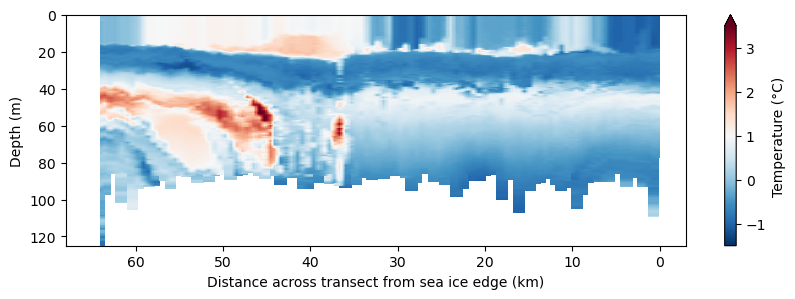

In [950]:
temp_da_interp.plot(y='depth',cmap='RdBu_r',vmin=-1.5,vmax=3.5,figsize=[10,3],cbar_kwargs={'label': "Temperature (°C)"})

plt.xlabel("Distance across transect from sea ice edge (km)")
plt.ylabel("Depth (m)")

plt.ylim(125,0)
plt.xlim(68,-3);

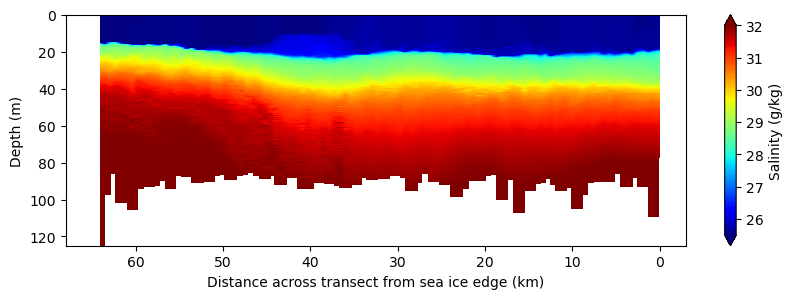

In [970]:
salt_da_interp.plot(y='depth',cmap='jet',vmin=25.5,vmax=32,figsize=[10,3],cbar_kwargs={'label': "Salinity (g/kg)"})

plt.xlabel("Distance across transect from sea ice edge (km)")
plt.ylabel("Depth (m)")

plt.ylim(125,0)
plt.xlim(68,-3);

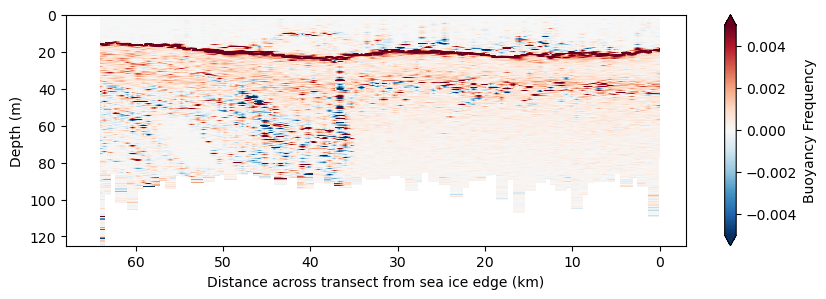

In [1142]:
N2_da_interp.plot(y='depth',cmap='RdBu_r',vmin=-0.005,vmax=0.005,figsize=[10,3],cbar_kwargs={'label': "Buoyancy Frequency"})

plt.xlabel("Distance across transect from sea ice edge (km)")
plt.ylabel("Depth (m)")

plt.ylim(125,0)
plt.xlim(68,-3);

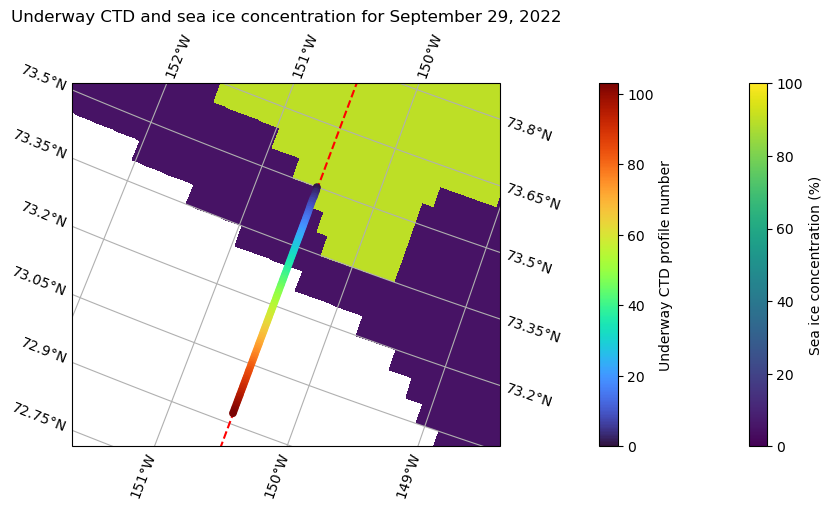

In [839]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-152, -149, 73, 73.6], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')

ice = ax.pcolormesh(siconc_over0_ds.sel(time='2022-09-29').lon.values,siconc_over0_ds.sel(time='2022-09-29').lat.values,siconc_over0_ds.sel(time='2022-09-29').isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())
fig.colorbar(ice, ax=ax,pad=0,label='Sea ice concentration (%)')
fig.colorbar(uctd, ax=ax,pad=0.1,label='Underway CTD profile number')
fig.tight_layout()

# add dashed line for selected sea ice data
x = [-150.5,-150.5]
y = [72,80]
ax.plot(x,y,linestyle='dashed',color='red',transform=ccrs.PlateCarree())

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

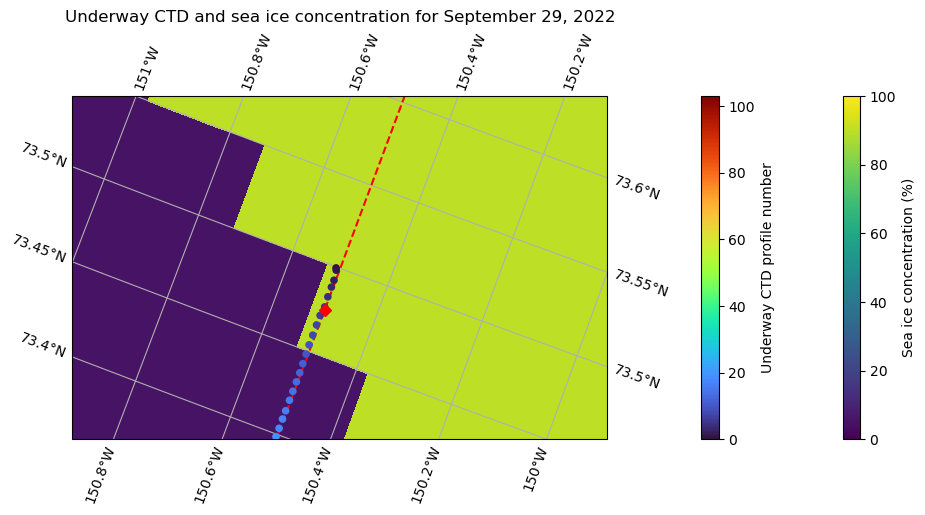

In [1020]:
fig, ax = plt.subplots(1,1,figsize=(12,5),  subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-130)})

ax.set_extent([-151, -150, 73.45, 73.55], ccrs.PlateCarree()) # (x0, x1, y0, y1) 
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

# add in situ data
uctd = ax.scatter(uctd_ds_20220929.longitude,uctd_ds_20220929.latitude,transform=ccrs.PlateCarree(),c=np.arange(len(uctd_ds_20220929.time)),s=20,zorder=5,cmap='turbo')

ice = ax.pcolormesh(siconc_over0_ds.sel(time='2022-09-29').lon.values,siconc_over0_ds.sel(time='2022-09-29').lat.values,siconc_over0_ds.sel(time='2022-09-29').isel(time=0).values*10,vmin=0,vmax=100,\
                    transform=ccrs.PlateCarree())

# add points for start and end of siconc line
plt.plot(-150.5,lat_along_150[transect_end_idx],'D',color='r',transform=ccrs.PlateCarree(),zorder=6)
plt.plot(-150.5,lat_along_150[transect_start_idx],'D',color='r',transform=ccrs.PlateCarree(),zorder=6)

fig.colorbar(ice, ax=ax,pad=0,label='Sea ice concentration (%)')
fig.colorbar(uctd, ax=ax,pad=0.1,label='Underway CTD profile number')
fig.tight_layout()

# add dashed line for selected sea ice data
x = [-150.5,-150.5]
y = [72,80]
ax.plot(x,y,linestyle='dashed',color='red',transform=ccrs.PlateCarree())

plt.title('Underway CTD and sea ice concentration for September 29, 2022');

In [849]:
uctd_ds_20220929.longitude.values[0:10]

array([-150.50811054, -150.5063036 , -150.50335051, -150.50338776,
       -150.50328977, -150.50217134, -150.50463848, -150.50470896,
       -150.50473538, -150.50469584])

This CTD transect is along ~150.5 deg West

In [1058]:
# identify y coord where longitude = -150.5 in sea ice conc dataset
print((siconc_ds.sel(time='2022-09-29').isel(time=0,y=695).lon.values-360)[0:10])

[-150.5 -150.5 -150.5 -150.5 -150.5 -150.5 -150.5 -150.5 -150.5 -150.5]


In [861]:
# identify start and end latitudinal coords in uCTD dataset
print(temp_da.isel(distance=0).latitude.values)
print(temp_da.isel(distance=-1).latitude.values)

73.49941975048849
72.92532078916904


In [148]:
# get indices of lat coords in sea ice dataset
lat_along_150 = siconc_ds.sel(time='2022-09-29').isel(y=695).lat.values

In [150]:
lat_along_150[350:400]

array([72.625, 72.675, 72.725, 72.775, 72.825, 72.875, 72.925, 72.975,
       73.025, 73.075, 73.125, 73.175, 73.225, 73.275, 73.325, 73.375,
       73.425, 73.475, 73.525, 73.575, 73.625, 73.675, 73.725, 73.775,
       73.825, 73.875, 73.925, 73.975, 74.025, 74.075, 74.125, 74.175,
       74.225, 74.275, 74.325, 74.375, 74.425, 74.475, 74.525, 74.575,
       74.625, 74.675, 74.725, 74.775, 74.825, 74.875, 74.925, 74.975,
       75.025, 75.075])

In [152]:
transect_end_idx = np.argmin(abs(lat_along_150-72.9))
transect_start_idx = np.argmin(abs(lat_along_150-73.5))

In [154]:
print(lat_along_150[transect_end_idx])
print(lat_along_150[transect_start_idx])

72.925
73.475


In [156]:
siconc_150W = siconc_ds.sel(time='2022-09-29').isel(time=0,y=695)

In [158]:
siconc_150W_transect = siconc_150W.iceconc.isel(x=slice(transect_end_idx, transect_start_idx+1))

In [160]:
siconc_150W_transect = siconc_150W_transect.rename({'lat':'latitude'})
siconc_150W_transect = siconc_150W_transect.rename({'lon':'longitude'})

In [162]:
def generate_distance_array(da):
    distance = [0] # add zero for first point

    for i in range(len(da.x)-1):
        # coordinates of two locations (latitude, longitude)
        coords_1 = (da.latitude.isel(x=i), da.longitude.isel(x=i))
        coords_2 = (da.latitude.isel(x=i+1), da.longitude.isel(x=i+1))
    
        # calculate distance
        distance.append(geodesic(coords_1, coords_2).kilometers)
    
    # calculate cumulative sum
    distance_cumsum = np.cumsum(distance)
    
    return distance_cumsum

In [164]:
distance_cumsum_siconc = generate_distance_array(siconc_150W_transect)

In [166]:
distance_cumsum_siconc

array([ 0.        ,  5.57984888, 11.15972531, 16.73962921, 22.31956052,
       27.89951916, 33.47950506, 39.05951815, 44.63955836, 50.21962562,
       55.79971986, 61.379841  ])

In [168]:
siconc_150W_transect

<xarray.DataArray 'iceconc' (x: 12)>
array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0.5, 0.5, 9. ])
Coordinates:
    latitude   (x) float64 72.92 72.97 73.03 73.08 ... 73.33 73.38 73.42 73.47
    longitude  (x) float64 209.5 209.5 209.5 209.5 ... 209.5 209.5 209.5 209.5
    time       datetime64[ns] 2022-09-29T00:30:00.000003
Dimensions without coordinates: x

In [170]:
distance_cumsum_siconc

array([ 0.        ,  5.57984888, 11.15972531, 16.73962921, 22.31956052,
       27.89951916, 33.47950506, 39.05951815, 44.63955836, 50.21962562,
       55.79971986, 61.379841  ])

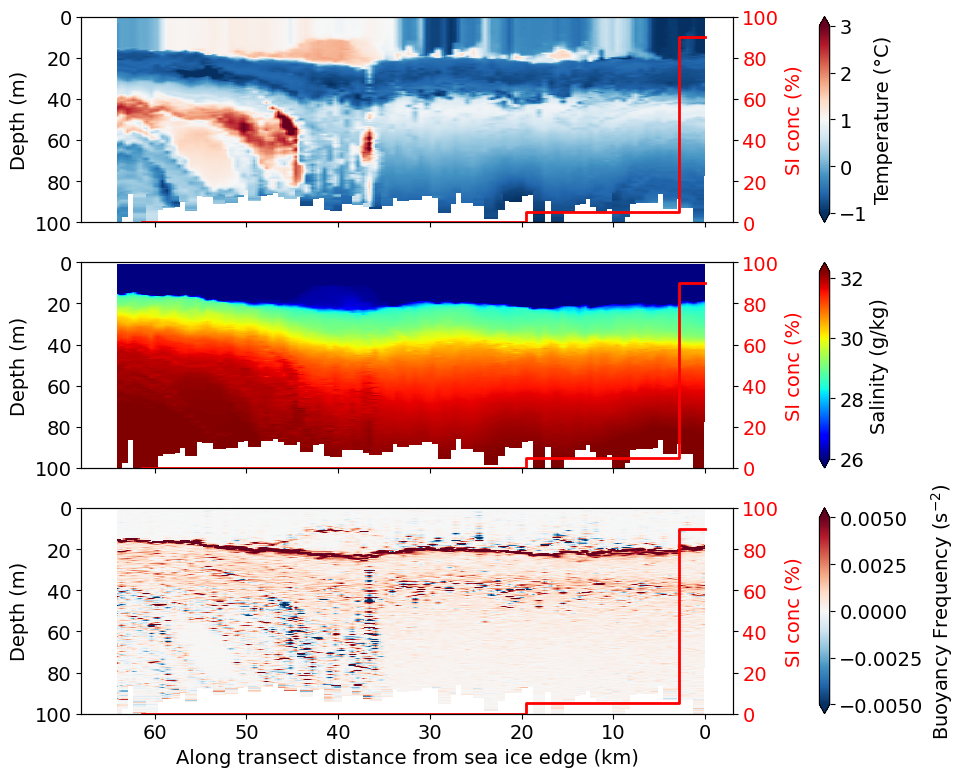

In [172]:
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=[10,8], sharex=True)

# plot temperature =======================
temp_da_interp.plot(ax=ax1,y='depth',cmap='RdBu_r',vmin=-1,vmax=3,cbar_kwargs={'label': "Temperature (°C)", 'pad':0.1})
ax1.set_xlabel("")

# Create a secondary y-axis
ax1_twin = ax1.twinx() 
ax1_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

# plot salinity =======================
salt_da_interp.plot(ax=ax2,y='depth',cmap='jet',vmin=26,vmax=32.2,cbar_kwargs={'label': "Salinity (g/kg)", 'pad':0.1})
ax2.set_xlabel("")

# Create a secondary y-axis
ax2_twin = ax2.twinx() 
ax2_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

# plot N2 =======================
N2_da_interp.plot(ax=ax3,y='depth',cmap='RdBu_r',vmin=-0.005,vmax=0.005,cbar_kwargs={'label': "Buoyancy Frequency (s$^{-2}$)",'pad':0.1})
ax3.set_xlabel("Along transect distance from sea ice edge (km)")

# Create a secondary y-axis
ax3_twin = ax3.twinx() 
ax3_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

for ax in (ax1,ax2,ax3):
    ax.set_ylim(100,0)
    ax.set_xlim(68,-3)
    ax.set_ylabel("Depth (m)")

for ax in (ax1_twin, ax2_twin, ax3_twin):    
    ax.tick_params(axis='y', labelcolor='r')
    ax.set_ylabel("SI conc (%)",color='r')
    ax.set_ylim(0,100);
    
plt.tight_layout()

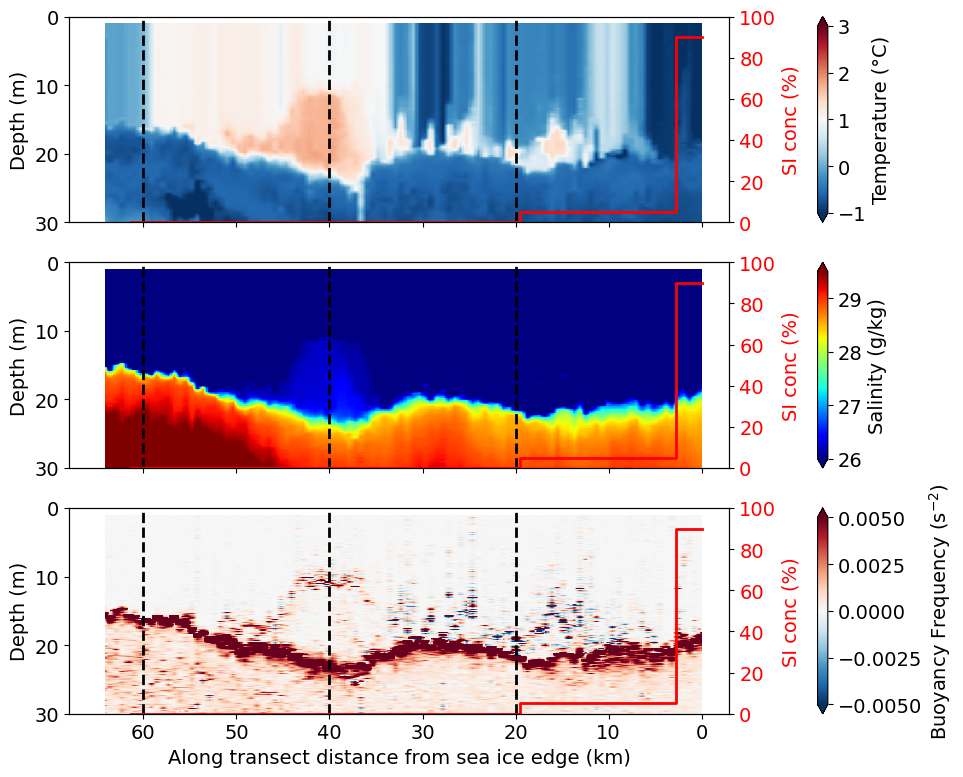

In [176]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=[10,8], sharex=True)

# plot temperature =======================
temp_da_interp.plot(ax=ax1,y='depth',cmap='RdBu_r',vmin=-1,vmax=3,cbar_kwargs={'label': "Temperature (°C)", 'pad':0.1})
ax1.set_xlabel("")

# Create a secondary y-axis
ax1_twin = ax1.twinx() 
ax1_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

# plot salinity =======================
salt_da_interp.plot(ax=ax2,y='depth',cmap='jet',vmin=26,vmax=29.5,cbar_kwargs={'label': "Salinity (g/kg)", 'pad':0.1})
ax2.set_xlabel("")

# Create a secondary y-axis
ax2_twin = ax2.twinx() 
ax2_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

# plot N2 =======================
N2_da_interp.plot(ax=ax3,y='depth',cmap='RdBu_r',vmin=-0.005,vmax=0.005,cbar_kwargs={'label': "Buoyancy Frequency (s$^{-2}$)",'pad':0.1})
ax3.set_xlabel("Along transect distance from sea ice edge (km)")

# Create a secondary y-axis
ax3_twin = ax3.twinx() 
ax3_twin.step(distance_cumsum_siconc,np.flip(siconc_150W_transect.values*10),'r', linewidth=2, where='mid')

for ax in (ax1,ax2,ax3):
    ax.set_ylim(30,0)
    ax.set_xlim(68,-3)
    ax.set_ylabel("Depth (m)")
    ax.axvline(x=20,linestyle='dashed',color='k',linewidth=2)
    ax.axvline(x=40,linestyle='dashed',color='k',linewidth=2)
    ax.axvline(x=60,linestyle='dashed',color='k',linewidth=2)

for ax in (ax1_twin, ax2_twin, ax3_twin):    
    ax.tick_params(axis='y', labelcolor='r')
    ax.set_ylabel("SI conc (%)",color='r')
    ax.set_ylim(0,100);
    
plt.tight_layout()

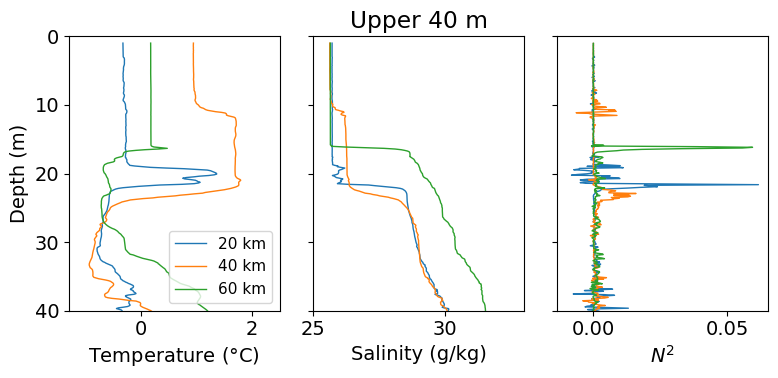

In [212]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[8,4])

# plot all underway ctd profiles
linewidth_size = 1

# temperature
temp_da.sel(distance=20,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:blue',linewidth=linewidth_size,label='20 km')
temp_da.sel(distance=40,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:orange',linewidth=linewidth_size,label='40 km')
temp_da.sel(distance=60,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:green',linewidth=linewidth_size,label='60 km')

# salinity
salt_da.sel(distance=20,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=40,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=60,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

# N2
N2_da.sel(distance=20,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=40,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=60,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(40,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-1.3,2.5)
ax2.set_xlim(25,33)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$")

ax1.legend(fontsize=11)

ax2.set_title("Upper 40 m")

plt.tight_layout()

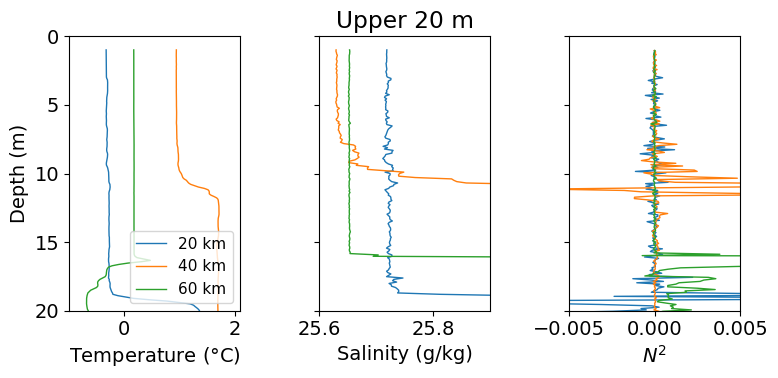

In [234]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[8,4])

# plot all underway ctd profiles
linewidth_size = 1

# temperature
temp_da.sel(distance=20,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:blue',linewidth=linewidth_size,label='20 km')
temp_da.sel(distance=40,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:orange',linewidth=linewidth_size,label='40 km')
temp_da.sel(distance=60,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:green',linewidth=linewidth_size,label='60 km')

# salinity
salt_da.sel(distance=20,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=40,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=60,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

# N2
N2_da.sel(distance=20,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=40,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=60,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(20,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-1,2.1)
# ax2.set_xlim(25,33)
ax2.set_xlim(25.6,25.9)
ax3.set_xlim(-0.005,0.005)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$")

ax1.legend(fontsize=11)

ax2.set_title("Upper 20 m")

plt.tight_layout()

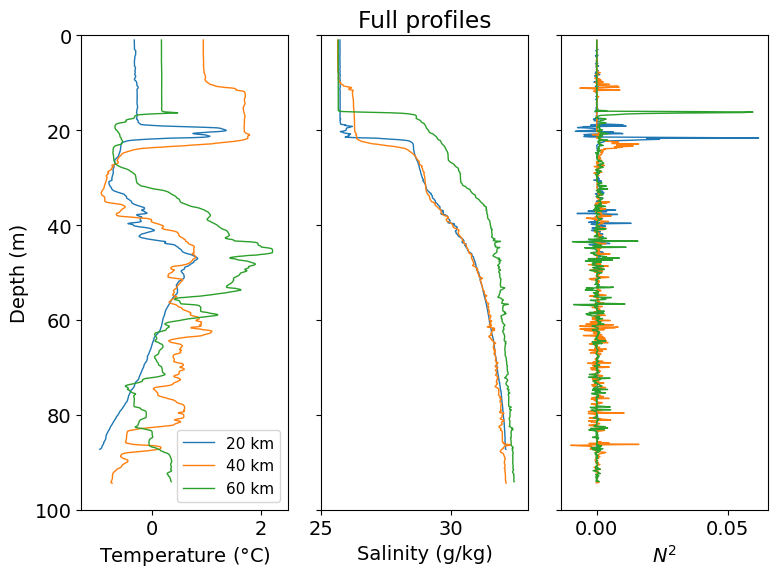

In [218]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[8,6])

# plot all underway ctd profiles
linewidth_size = 1

# temperature
temp_da.sel(distance=20,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:blue',linewidth=linewidth_size,label='20 km')
temp_da.sel(distance=40,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:orange',linewidth=linewidth_size,label='40 km')
temp_da.sel(distance=60,method='nearest').plot(ax=ax1,y='depth',hue='time',c='tab:green',linewidth=linewidth_size,label='60 km')

# salinity
salt_da.sel(distance=20,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=40,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
salt_da.sel(distance=60,method='nearest').plot(ax=ax2,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

# N2
N2_da.sel(distance=20,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:blue',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=40,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:orange',add_legend=False,linewidth=linewidth_size)
N2_da.sel(distance=60,method='nearest').plot(ax=ax3,y='depth',hue='time',c='tab:green',add_legend=False,linewidth=linewidth_size)

for ax in (ax1,ax2,ax3):
    ax.set_ylim(100,0)
    ax.axhline(y=-15,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    
# standardize x limits
ax1.set_xlim(-1.3,2.5)
ax2.set_xlim(25,33)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("$N^2$")

ax1.legend(fontsize=11)

ax2.set_title("Full profiles")

plt.tight_layout()